# CW_04
# 2F and 4F systems

In this notebook you will explore the simple 2F system and how you can combine two of them to produce a 4F system. The angular spectrum method and an exhaustive plotting routine are provided for you to use, but you will be responsible for implementing everything else. After you have familiarized yourself with the provided code, proceed to part 1.

In [1]:
# - No modification necessary -
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from scipy.interpolate import interp1d

# Grid parameters
N = 512
dx = 4e-6   # pixel spacing (meters)

x = (np.arange(-N//2, N//2)) * dx
X, Y = np.meshgrid(x, x)

# Frequency coordinates
fx = np.fft.fftfreq(N, dx)
FX, FY = np.meshgrid(fx, fx)

# Optical parameters
wavelength = 532e-9
k = 2 * np.pi / wavelength

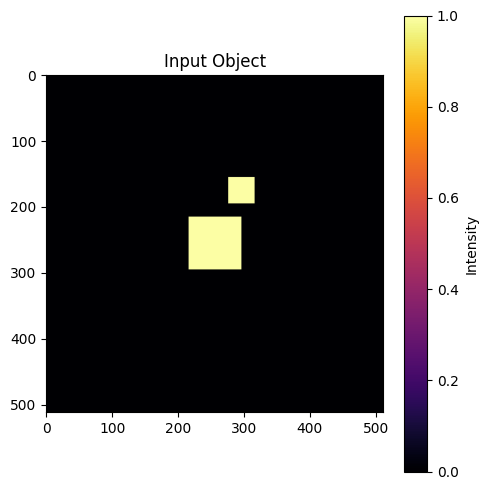

In [2]:
# - No modification necessary -

def make_input_object():
    obj = np.zeros((N, N))

    obj[N//2-40:N//2+40, N//2-40:N//2+40] = 1

    obj[N//2-100:N//2-60, N//2+20:N//2+60] = 1

    return obj.astype(np.complex64)

U0 = make_input_object()
intensity = np.abs(U0)**2 
plt.figure(figsize=(5,5))
plt.imshow(intensity, cmap='inferno')
plt.title("Input Object")
plt.colorbar(label="Intensity")
plt.tight_layout()
plt.show()

In [3]:
# - No modification necessary -

def plot_field(U_in, cross, U_out, z_positions):
    """
    Plot input intensity, x-z propagation cross section, and output intensity.

    Parameters
    ----------
    U_in : complex ndarray
        Input field
    cross : ndarray
        x-z intensity cross section (Nx, Nz)
    U_out : complex ndarray
        Output field
    z_positions : ndarray
        Physical z positions corresponding to propagation samples
    """

    # ---- interpolate to uniform z grid for plotting ----
    z_uniform = np.linspace(z_positions.min(), z_positions.max(), len(z_positions))

    interp = interp1d(z_positions, cross.T, axis=0, kind='linear')
    cross_uniform = interp(z_uniform).T

    # log intensity for visualization
    display_data = np.log10(cross_uniform + 1e-12)

    fig, axs = plt.subplots(1, 3, figsize=(18,5))

    # -----------------------------
    # Input intensity
    # -----------------------------
    input_intensity = np.abs(U_in)**2

    im0 = axs[0].imshow(input_intensity, cmap="inferno")
    axs[0].set_title("Input Intensity")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")

    plt.colorbar(im0, ax=axs[0], label="Intensity")

    # -----------------------------
    # Propagation cross section
    # -----------------------------
    im1 = axs[1].imshow(
        display_data,
        aspect='auto',
        origin='lower',
        cmap='inferno',
        extent=[
            z_uniform.min()*1e3,
            z_uniform.max()*1e3,
            -1,
            1
        ]
    )

    axs[1].set_xlabel("Propagation distance (mm)")
    axs[1].set_ylabel("x cross-section")
    axs[1].set_title("Beam Propagation Cross-section")

    plt.colorbar(im1, ax=axs[1], label="log10(Intensity)")

    # -----------------------------
    # Output intensity
    # -----------------------------
    output_intensity = np.abs(U_out)**2

    im2 = axs[2].imshow(output_intensity, cmap="inferno")
    axs[2].set_title("Output Intensity")
    axs[2].set_xlabel("x")
    axs[2].set_ylabel("y")

    plt.colorbar(im2, ax=axs[2], label="Intensity")

    plt.tight_layout()
    plt.show()

In [4]:
# - No modification necessary - 

def angular_spectrum_propagate(U_in, z, n_steps=100):
    """
    Angular spectrum propagation that records an x-z intensity cross section.

    Returns
    -------
    cross_section : array (Nx, n_steps)
    z_positions : array (n_steps,)
    U_final : complex field
    """

    dz = z / n_steps

    U = U_in.copy()

    U_f = np.fft.fft2(U)

    kx = 2*np.pi*FX
    ky = 2*np.pi*FY

    kz = np.sqrt(np.maximum(0, k**2 - kx**2 - ky**2))

    H = np.exp(1j * kz * dz)

    cross = []

    for i in range(n_steps):

        U_f = U_f * H
        U = np.fft.ifft2(U_f)

        intensity_slice = np.abs(U[:, N//2])**2
        cross.append(intensity_slice)

        U_f = np.fft.fft2(U)

    cross = np.array(cross).T

    z_positions = np.linspace(dz, z, n_steps)

    return cross, z_positions, U

# Part 1

In this part of the notebook you will implement a simple 2F system, which will take an input and produce the Fourier transform of it as an output.

To do this, you will implement the function twof_system, which takes an input field and a focal length as inputs, and returns as an output the cross-section of propagation, the sampled z positions, and the output field. Note that the provided angular spectrum propagation function already provides outputs in this format, so you can look to that to better understand how to format your function.

After you have implemented the function, run the visualize_2f function to verify that your output seems reasonable. Then answer the following questions:

1) We say that the output is a Fourier transform, which we normally think of as having coordinates in frequency space. In this system, however, our optical beam will exist in real space at the Fourier plane. In what physical coordinates does it exist, then? Try doing the derivation yourself.
2) Does changing the focal length in the simulation match the analytical result that you have derived?

In [5]:
def twof_system(U_in, f):
    """
    Simulate a 2f optical system using angular spectrum propagation.

    Parameters
    ----------
    U_in : ndarray
        Complex input field.
    f : float
        Lens focal length and propagation distance.

    Returns
    -------
    cross : ndarray
        Field cross-sections along propagation.
    z_positions : ndarray
        Corresponding axial positions.
    U : ndarray
        Complex field at the output plane.
    """
    
    cross_sections = []
    z_all = []

    z_offset = 0

    # propagate to lens
    cross1, z1, U = angular_spectrum_propagate(U_in, f)
    cross_sections.append(cross1)
    z_all.append(z1 + z_offset)

    z_offset = z_all[-1][-1]

    # apply lens
    U *= np.exp(-1j * k/(2*f) * (X**2 + Y**2))

    # propagate to output
    cross2, z2, U = angular_spectrum_propagate(U, f)
    cross_sections.append(cross2)
    z_all.append(z2 + z_offset)

    cross = np.concatenate(cross_sections, axis=1)
    z_positions = np.concatenate(z_all)

    return cross, z_positions, U

In [6]:
# - No modification necessary -

def visualize_2f(f):
    cross, z_positions, U_out = twof_system(U0, f)
    plot_field(U0, cross, U_out, z_positions)
    
interact(
    visualize_2f,
    f=FloatSlider(min=0.05, max=0.3, step=0.01, value=0.1)
)

interactive(children=(FloatSlider(value=0.1, description='f', max=0.3, min=0.05, step=0.01), Output()), _dom_c…

<function __main__.visualize_2f(f)>

## Discussion
1) One way to think about how the "Fourier" plane is mapped into real space is to think of the lens as capturing the different spatial frequencies that are emanating from the object and collimating them. This means that wef can think about a spatial frequency $k_{transverse}$ propagating at angle $\theta$ relative to the optical axis as being mapped to a spatial coordinate of radius $r=tan( \theta ) f$ or more completely $(x', y') = (tan( \theta_x ) f, tan( \theta_y ) f)$. This gives us $(x', y') = (\frac{k_x}{k_z} f, \frac{k_y}{k_z} f)$, or approximately $(x', y') = (\frac{k_x}{k} f, \frac{k_y}{k} f)$, which we can in turn simplify to $(x', y') = (\lambda f_x f, \lambda f_y f)$. Alternatively, we can write the inverse, $(f_x, f_y) = (\frac{x'}{\lambda  f}, \frac{y'}{\lambda  f})$, which directly tells us which spatial frequency lives at each point in the real Fourier plane.
2) As the focal length of the lens increases, we observe that the size of the output increases as well. This does match our analytical formula, which suggests that the spatial coordinate each frequency is mapped to is proportional to f.

# Part 2

Now that you have modeled a 2F system, let's combine two of them to produce a 4F system.

To do this, implement the function fourf_system. Leverage your twof_system function to do this for simplicity. As before, this function should return the cross-section of propagation, the sampled z coordinates, and the final output field.

Once you have completed your implementation, run the visualize_4f function to see your output and answer the following questions:

1) What do you observe about the output of your system. Is this what you expected? If the output deviates from your expectations, what might be causing this, and how could we improve it?
2) What happens when you change the focal lengths of the lenses? How can we relate the two focal lengths of the magnification of the output?

In [7]:
def fourf_system(U_in, f1, f2):
    """
    Simulate a 4f system composed of two sequential 2f systems.

    Parameters
    ----------
    U_in : ndarray
        Complex input field.
    f1 : float
        Focal length of the first 2f stage.
    f2 : float
        Focal length of the second 2f stage.

    Returns
    -------
    cross : ndarray
        Field cross-sections along propagation.
    z_positions : ndarray
        Corresponding axial positions.
    U : ndarray
        Complex field at the final output plane.
    """
    
    cross_sections = []
    z_all = []

    z_offset = 0

    # first lens system
    cross1, z1, U = twof_system(U_in, f1)
    cross_sections.append(cross1)
    z_all.append(z1 + z_offset)

    z_offset = z_all[-1][-1]

    # propagate to second lens
    cross2, z2, U = twof_system(U, f2)
    cross_sections.append(cross2)
    z_all.append(z2 + z_offset)

    cross = np.concatenate(cross_sections, axis=1)
    z_positions = np.concatenate(z_all)

    return cross, z_positions, U

In [8]:
# - No modification necessary -

def visualize_4f(f1, f2):

    cross, z_positions, U_out = fourf_system(U0, f1, f2)

    plot_field(U0, cross, U_out, z_positions)


interact(
    visualize_4f,
    f1=FloatSlider(min=0.05, max=0.3, step=0.01, value=0.1),
    f2=FloatSlider(min=0.05, max=0.3, step=0.01, value=0.1)
)

interactive(children=(FloatSlider(value=0.1, description='f1', max=0.3, min=0.05, step=0.01), FloatSlider(valu…

<function __main__.visualize_4f(f1, f2)>

## Discussion
1) The output image appears to be a copy of the input that has been mirrored on the x and y axes. Theoretically, we should see a perfect recreation of the input object, but in our simulation the output has a significant amount of error. This most likely occurs due to the finite simulation domain acting as a low-pass filter that blocks higher spatial frequencies from entering the 4F system. Increasing the size of the simulation domain (either by increasing N or dx) would help alleviate this and should give us a better reconstruction of our image at the output.
2) As the focal lengths of the lenses change, the size of the output image also changes. We can see from simple ray-diagram of collimated rays passing through the system (which we note is exactly a telescope) that the magnification of our system will be $-\frac{f_2}{f_1}$.  

# Part 3

Now that we have built a 4F system, let's try adding a filter to the Fourier plane to see how this effects our output.

Recall the relationship you have derived between coordinates in the Fourier plane and the spatial frequency that is encoded there. Then implement the following functions:
1) fourf_with_filter
2) high_pass_filter
3) low_pass_filter

Once you have done this, take some time to reflect on what you observe and how it aligns with your intuition for what the filters should be doing. No discussion questions need to be answered for this section.

In [9]:
def fourf_with_filter(U_in, f1, f2, spatial_filter):
    """
    Simulate a 4f system with a spatial filter at the intermediate plane.

    Parameters
    ----------
    U_in : ndarray
        Complex input field.
    f1 : float
        Focal length of the first 2f stage.
    f2 : float
        Focal length of the second 2f stage.
    spatial_filter : ndarray
        Multiplicative spatial filter applied between stages.

    Returns
    -------
    cross : ndarray
        Field cross-sections along propagation.
    z_positions : ndarray
        Corresponding axial positions.
    U : ndarray
        Complex field at the final output plane.
    """
    
    cross_sections = []
    z_all = []

    z_offset = 0

    # first lens system
    cross1, z1, U = twof_system(U_in, f1)
    cross_sections.append(cross1)
    z_all.append(z1 + z_offset)

    z_offset = z_all[-1][-1]
    
    U *= spatial_filter

    # propagate to second lens
    cross2, z2, U = twof_system(U, f2)
    cross_sections.append(cross2)
    z_all.append(z2 + z_offset)

    cross = np.concatenate(cross_sections, axis=1)
    z_positions = np.concatenate(z_all)

    return cross, z_positions, U

In [10]:
def high_pass_filter(radius):
    """
    Create a circular high-pass spatial filter.

    Parameters
    ----------
    radius : float
        Cutoff radius.

    Returns
    -------
    filt : ndarray
        Binary mask passing frequencies outside the radius.
    """
    
    r = np.sqrt(X**2 + Y**2)

    filt = np.ones_like(r)
    filt[r < radius] = 0

    return filt

In [11]:
# - No modification necessary -

def interactive_HP_filter(radius):

    filt = high_pass_filter(radius)

    cross, z_positions, U = fourf_with_filter(U0, 0.1, 0.1, filt)

    plot_field(U0, cross, U, z_positions)


interact(
    interactive_HP_filter,
    radius=FloatSlider(min=1e-5, max=2e-3, step=1e-5, value=5e-4)
)

interactive(children=(FloatSlider(value=0.0005, description='radius', max=0.002, min=1e-05, step=1e-05), Outpu…

<function __main__.interactive_HP_filter(radius)>

In [12]:
def low_pass_filter(radius):
    """
    Create a circular low-pass spatial filter.

    Parameters
    ----------
    radius : float
        Cutoff radius.

    Returns
    -------
    filt : ndarray
        Binary mask passing frequencies inside the radius.
    """
    
    r = np.sqrt(X**2 + Y**2)

    filt = np.zeros_like(r)
    filt[r < radius] = 1

    return filt

In [13]:
# - No modification necessary

def interactive_LP_filter(radius):

    filt = low_pass_filter(radius)

    cross, dz, U = fourf_with_filter(U0, 0.1, 0.1, filt)

    plot_field(U0, cross, U, dz)


interact(
    interactive_LP_filter,
    radius=FloatSlider(min=1e-5, max=2e-3, step=1e-5, value=5e-4)
)

interactive(children=(FloatSlider(value=0.0005, description='radius', max=0.002, min=1e-05, step=1e-05), Outpu…

<function __main__.interactive_LP_filter(radius)>